In [1]:
ROLL_NO = 1024170004       # <-- your full roll number
NAME = "Dhruv Agrawal"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170004   Name: Dhruv Agrawal   Fingerprint: 7A9F4E9D   Tickets: 16

Ticket_ID                                                                             Ticket_Text
      T01                         The MATLAB crashes while opening. It works on another computer.
      T02                                          The printer failed to open. Please resolve it.
      T03                        The MATLAB keeps asking for login. It works on another computer.
      T04              I tried restarting the MATLAB after restarting the system. This is urgent.
      T05                                            Call me on +91 98765 43210 or 0175-239-3201.
      T06                                                  Only 2 of 30 PCs boot after 3.5 hours.
      T07                                                      Dr. Rao's lab PC (No. 14) is down.
      T08 I was locked out of the laptop when I use mobile hotspot. It works on another computer.
      T09       VPN stopped respo

In [6]:
processed_tickets = [process_ticket(text) for text in df["Ticket_Text"]]

rows = []

for i, result in enumerate(processed_tickets, 1):
    rows.append({
        "Ticket": f"T{i:02d}",
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation Tokens": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique Tokens": len(set(result["tokens"])),
        "Final Tokens": len(result["final"])
    })

q1_table = pd.DataFrame(rows)

total_row = {
    "Ticket": "TOTAL",
    "Sentences": q1_table["Sentences"].sum(),
    "Tokens": q1_table["Tokens"].sum(),
    "Punctuation Tokens": q1_table["Punctuation Tokens"].sum(),
    "Stopwords": q1_table["Stopwords"].sum(),
    "Unique Tokens": q1_table["Unique Tokens"].sum(),
    "Final Tokens": q1_table["Final Tokens"].sum()
}

q1_table = pd.concat(
    [q1_table, pd.DataFrame([total_row])],
    ignore_index=True
)

q1_table

,Ticket,Sentences,Tokens,Punctuation Tokens,Stopwords,Unique Tokens,Final Tokens
0,T01,2,12,2,4,11,6
1,T02,2,10,2,3,9,5
2,T03,2,13,2,4,12,7
3,T04,2,14,2,6,11,6
4,T05,1,9,1,3,9,5
5,T06,1,10,1,3,10,6
6,T07,2,13,4,3,12,6
7,T08,2,19,2,9,17,8
8,T09,2,15,2,5,14,8
9,T10,2,14,2,5,12,7


In [7]:
ticket = processed_tickets[0]

print("TOKENS:")
print(ticket["tokens"])

print("\nPUNCTUATION TOKENS:")
print(ticket["punct"])

print("\nSTOPWORDS:")
print(ticket["stops"])

print("\nFINAL TOKENS:")
print(ticket["final"])

TOKENS:
['the', 'matlab', 'crashes', 'while', 'opening', '.', 'it', 'works', 'on', 'another', 'computer', '.']

PUNCTUATION TOKENS:
['.', '.']

STOPWORDS:
['the', 'while', 'it', 'on']

FINAL TOKENS:
['matlab', 'crashes', 'opening', 'works', 'another', 'computer']


In [9]:
import re

long_words = []

for text in df["Ticket_Text"]:
    long_words.append(re.findall(r"\b[A-Za-z]{6,}\b", text))

for i, words in enumerate(long_words, 1):
    print(f"T{i:02d}:", words)

T01: ['MATLAB', 'crashes', 'opening', 'another', 'computer']
T02: ['printer', 'failed', 'Please', 'resolve']
T03: ['MATLAB', 'asking', 'another', 'computer']
T04: ['restarting', 'MATLAB', 'restarting', 'system', 'urgent']
T05: []
T06: []
T07: []
T08: ['locked', 'laptop', 'mobile', 'hotspot', 'another', 'computer']
T09: ['stopped', 'responding', 'before', 'assignment', 'deadline', 'changed']
T10: ['restarting', 'uploading', 'worked', 'yesterday']
T11: ['student', 'portal', 'showing', 'several']
T12: ['unable', 'student', 'portal', 'during', 'Please']
T13: ['stopped', 'responding', 'urgent']
T14: ['portal', 'opening']
T15: ['stopped', 'syncing', 'Please', 'resolve']
T16: ['showing', 'restarting', 'system', 'another', 'solution']


In [10]:
numbers = []

for text in df["Ticket_Text"]:
    numbers.append(re.findall(r"\b\d+(?:\.\d+)+\b|\b\d+\b", text))

for i, nums in enumerate(numbers, 1):
    print(f"T{i:02d}:", nums)

T01: []
T02: []
T03: []
T04: []
T05: ['91', '98765', '43210', '0175', '239', '3201']
T06: ['2', '30', '3.5']
T07: ['14']
T08: []
T09: []
T10: []
T11: []
T12: []
T13: []
T14: []
T15: []
T16: []


In [11]:
capitalized_words = []

for text in df["Ticket_Text"]:
    capitalized_words.append(re.findall(r"\b[A-Z][a-zA-Z]*\b", text))

for i, words in enumerate(capitalized_words, 1):
    print(f"T{i:02d}:", words)

T01: ['The', 'MATLAB', 'It']
T02: ['The', 'Please']
T03: ['The', 'MATLAB', 'It']
T04: ['I', 'MATLAB', 'This']
T05: ['Call']
T06: ['Only', 'PCs']
T07: ['Dr', 'Rao', 'PC', 'No']
T08: ['I', 'I', 'It']
T09: ['VPN', 'I']
T10: ['I', 'It']
T11: ['The', 'I']
T12: ['I', 'Please']
T13: ['The', 'This']
T14: ['Why']
T15: ['The', 'Please']
T16: ['Lms', 'Is']


In [12]:
vowel_words = []

for text in df["Ticket_Text"]:
    vowel_words.append(re.findall(r"\b[AEIOUaeiou][A-Za-z]*\b", text))

for i, words in enumerate(vowel_words, 1):
    print(f"T{i:02d}:", words)

T01: ['opening', 'It', 'on', 'another']
T02: ['open', 'it']
T03: ['asking', 'It', 'on', 'another']
T04: ['I', 'after', 'is', 'urgent']
T05: ['on', 'or']
T06: ['Only', 'of', 'after']
T07: ['is']
T08: ['I', 'out', 'of', 'I', 'use', 'It', 'on', 'another']
T09: ['assignment', 'I']
T10: ['I', 'uploading', 'It']
T11: ['is', 'an', 'error', 'I']
T12: ['I', 'am', 'unable', 'use']
T13: ['is', 'urgent']
T14: ['isn', 'opening']
T15: ['it']
T16: ['is', 'an', 'error', 'after', 'Is', 'another']


In [13]:
email_replaced = []

for text in df["Ticket_Text"]:
    replaced = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        "<EMAIL>",
        text
    )
    email_replaced.append(replaced)

for i, text in enumerate(email_replaced, 1):
    print(f"T{i:02d}:", text)

T01: The MATLAB crashes while opening. It works on another computer.
T02: The printer failed to open. Please resolve it.
T03: The MATLAB keeps asking for login. It works on another computer.
T04: I tried restarting the MATLAB after restarting the system. This is urgent.
T05: Call me on +91 98765 43210 or 0175-239-3201.
T06: Only 2 of 30 PCs boot after 3.5 hours.
T07: Dr. Rao's lab PC (No. 14) is down.
T08: I was locked out of the laptop when I use mobile hotspot. It works on another computer.
T09: VPN stopped responding before the assignment deadline. I don't know what changed.
T10: I tried restarting the lms while uploading the file. It worked yesterday.
T11: The student portal is showing an error. I have tried several times!
T12: I am unable to use the student portal during the lab. Please help.
T13: The lms stopped responding. This is urgent.
T14: Why isn't the portal opening?
T15: The wifi has stopped syncing. Please resolve it.
T16: Lms is showing an error after restarting the sys

In [14]:
url_replaced = []

for text in df["Ticket_Text"]:
    replaced = re.sub(
        r"https?://[^\s]+|www\.[^\s]+",
        "<URL>",
        text
    )
    url_replaced.append(replaced)

for i, text in enumerate(url_replaced, 1):
    print(f"T{i:02d}:", text)

T01: The MATLAB crashes while opening. It works on another computer.
T02: The printer failed to open. Please resolve it.
T03: The MATLAB keeps asking for login. It works on another computer.
T04: I tried restarting the MATLAB after restarting the system. This is urgent.
T05: Call me on +91 98765 43210 or 0175-239-3201.
T06: Only 2 of 30 PCs boot after 3.5 hours.
T07: Dr. Rao's lab PC (No. 14) is down.
T08: I was locked out of the laptop when I use mobile hotspot. It works on another computer.
T09: VPN stopped responding before the assignment deadline. I don't know what changed.
T10: I tried restarting the lms while uploading the file. It worked yesterday.
T11: The student portal is showing an error. I have tried several times!
T12: I am unable to use the student portal during the lab. Please help.
T13: The lms stopped responding. This is urgent.
T14: Why isn't the portal opening?
T15: The wifi has stopped syncing. Please resolve it.
T16: Lms is showing an error after restarting the sys

In [15]:
phone_replaced = []

for text in df["Ticket_Text"]:
    replaced = re.sub(
        r"(?<!\d)(?:\+?\d[\d\s().-]{7,}\d)(?!\d)",
        "<PHONE>",
        text
    )
    phone_replaced.append(replaced)

for i, text in enumerate(phone_replaced, 1):
    print(f"T{i:02d}:", text)

T01: The MATLAB crashes while opening. It works on another computer.
T02: The printer failed to open. Please resolve it.
T03: The MATLAB keeps asking for login. It works on another computer.
T04: I tried restarting the MATLAB after restarting the system. This is urgent.
T05: Call me on <PHONE> or <PHONE>.
T06: Only 2 of 30 PCs boot after 3.5 hours.
T07: Dr. Rao's lab PC (No. 14) is down.
T08: I was locked out of the laptop when I use mobile hotspot. It works on another computer.
T09: VPN stopped responding before the assignment deadline. I don't know what changed.
T10: I tried restarting the lms while uploading the file. It worked yesterday.
T11: The student portal is showing an error. I have tried several times!
T12: I am unable to use the student portal during the lab. Please help.
T13: The lms stopped responding. This is urgent.
T14: Why isn't the portal opening?
T15: The wifi has stopped syncing. Please resolve it.
T16: Lms is showing an error after restarting the system. Is there 

In [16]:
from nltk.tokenize import RegexpTokenizer

token_pattern = r"""https?://\S+|[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}|\+?\d[\d\s().-]{7,}\d|\d+(?:\.\d+)+|[A-Za-z]+(?:[-'][A-Za-z]+)+|[A-Za-z]+|[^\w\s]"""

tokenizer = RegexpTokenizer(token_pattern)

def my_tokenize(text):
    return tokenizer.tokenize(text)

In [18]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work."
]
for line in TEST_LINES:
    print("RAW:", line)
    print("TOKENS:", my_tokenize(line))
    print()

RAW: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
TOKENS: ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www', '.', 'thapar', '.', 'edu', '/', 'it', '.']

RAW: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
TOKENS: ['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', ',', '.']

RAW: The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
TOKENS: ['The', 'state-of-the-art', 'lab', "isn't", 'open', ';', 'log-in', 'at', '5.30', 'p', '.', 'm', '.', "didn't", 'work', '.']



In [19]:
for _, row in df.iterrows():
    print(f"{row['Ticket_ID']}:")
    print(my_tokenize(row["Ticket_Text"]))
    print()

T01:
['The', 'MATLAB', 'crashes', 'while', 'opening', '.', 'It', 'works', 'on', 'another', 'computer', '.']

T02:
['The', 'printer', 'failed', 'to', 'open', '.', 'Please', 'resolve', 'it', '.']

T03:
['The', 'MATLAB', 'keeps', 'asking', 'for', 'login', '.', 'It', 'works', 'on', 'another', 'computer', '.']

T04:
['I', 'tried', 'restarting', 'the', 'MATLAB', 'after', 'restarting', 'the', 'system', '.', 'This', 'is', 'urgent', '.']

T05:
['Call', 'me', 'on', '+91 98765 43210', 'or', '0175-239-3201', '.']

T06:
['Only', 'of', 'PCs', 'boot', 'after', '3.5', 'hours', '.']

T07:
['Dr', '.', "Rao's", 'lab', 'PC', '(', 'No', '.', ')', 'is', 'down', '.']

T08:
['I', 'was', 'locked', 'out', 'of', 'the', 'laptop', 'when', 'I', 'use', 'mobile', 'hotspot', '.', 'It', 'works', 'on', 'another', 'computer', '.']

T09:
['VPN', 'stopped', 'responding', 'before', 'the', 'assignment', 'deadline', '.', 'I', "don't", 'know', 'what', 'changed', '.']

T10:
['I', 'tried', 'restarting', 'the', 'lms', 'while', 'u

In [20]:
from nltk.tokenize import word_tokenize

for line in TEST_LINES:
    print("RAW:", line)
    print("my_tokenize():", my_tokenize(line))
    print("word_tokenize():", word_tokenize(line))
    print("-" * 80)

RAW: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
my_tokenize(): ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www', '.', 'thapar', '.', 'edu', '/', 'it', '.']
word_tokenize(): ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']
--------------------------------------------------------------------------------
RAW: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
my_tokenize(): ['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', ',', '.']
word_tokenize(): ['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'R

In [21]:
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
import nltk
import pandas as pd

porter = PorterStemmer()
lancaster = LancasterStemmer()
regexp_stemmer = RegexpStemmer(r"ing$", min=4)
lemmatizer = WordNetLemmatizer()

# Get unique final tokens
unique_final_tokens = sorted(set(
    token
    for result in processed_tickets
    for token in result["final"]
))

# POS conversion for WordNet
def wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

# POS-tag all unique final tokens
pos_tags = nltk.pos_tag(unique_final_tokens)

results = []

for word, tag in pos_tags:
    porter_result = porter.stem(word)
    lancaster_result = lancaster.stem(word)
    regexp_result = regexp_stemmer.stem(word)
    lemma_result = lemmatizer.lemmatize(word, wordnet_pos(tag))

    # Keep only words where at least two methods differ
    if len(set([
        porter_result,
        lancaster_result,
        regexp_result,
        lemma_result
    ])) > 1:

        results.append({
            "Word": word,
            "Porter": porter_result,
            "Lancaster": lancaster_result,
            "Regexp": regexp_result,
            "WordNet Lemma": lemma_result
        })

q4_table = pd.DataFrame(results)

q4_table

,Word,Porter,Lancaster,Regexp,WordNet Lemma
0,another,anoth,anoth,another,another
1,assignment,assign,assign,assignment,assignment
2,call,call,cal,call,call
3,changed,chang,chang,changed,change
4,computer,comput,comput,computer,computer
5,crashes,crash,crash,crashes,crash
6,deadline,deadlin,deadlin,deadline,deadline
7,error,error,er,error,error
8,failed,fail,fail,failed,fail
9,file,file,fil,file,file


In [22]:
# S1: all tokens
S1 = [token for result in processed_tickets for token in result["tokens"]]

# S2: tokens without punctuation
S2 = [
    token
    for result in processed_tickets
    for token in result["tokens"]
    if token not in result["punct"]
]

# S3: final tokens
S3 = [token for result in processed_tickets for token in result["final"]]

# S4: S3 after Porter stemming
S4 = [porter.stem(token) for token in S3]


def corpus_stats(tokens):
    total = len(tokens)
    unique = len(set(tokens))
    ttr = unique / total if total else 0
    return total, unique, ttr


stats = pd.DataFrame(
    [
        corpus_stats(S1),
        corpus_stats(S2),
        corpus_stats(S3),
        corpus_stats(S4)
    ],
    index=["S1", "S2", "S3", "S4"],
    columns=["Total Tokens", "Unique Tokens", "TTR"]
)

stats

,Total Tokens,Unique Tokens,TTR
S1,199,98,0.492462
S2,168,93,0.553571
S3,97,64,0.659794
S4,97,61,0.628866


In [23]:
from collections import Counter

print("Top 10 words of S1:")
print(Counter(S1).most_common(10))

print("\nTop 10 words of S3:")
print(Counter(S3).most_common(10))

Top 10 words of S1:
[('.', 26), ('the', 16), ('i', 7), ('is', 7), ('it', 6), ('on', 4), ('another', 4), ('restarting', 4), ('matlab', 3), ('works', 3)]

Top 10 words of S3:
[('another', 4), ('restarting', 4), ('matlab', 3), ('works', 3), ('computer', 3), ('please', 3), ('tried', 3), ('stopped', 3), ('lms', 3), ('portal', 3)]


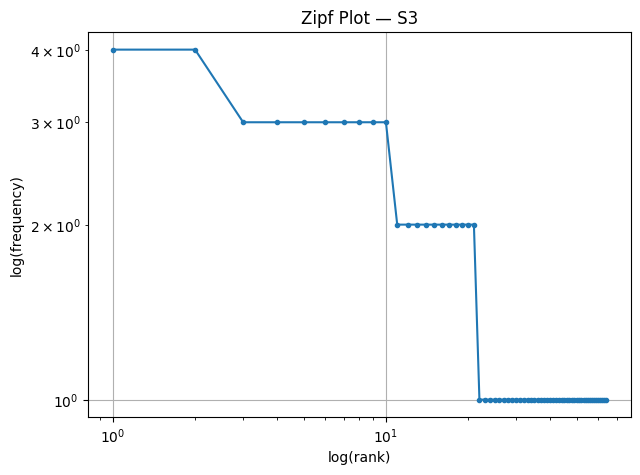

In [25]:
import matplotlib.pyplot as plt

freqs = sorted(Counter(S3).values(), reverse=True)
ranks = list(range(1, len(freqs) + 1))

plt.figure(figsize=(7, 5))
plt.loglog(ranks, freqs, marker=".")
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("Zipf Plot — S3")
plt.grid(True)
plt.show()

In [28]:
print("Top 5 bigrams of S1:")
print(Counter(zip(S1[:-1], S1[1:])).most_common(5))

print("\nTop 5 bigrams of S3:")
print(Counter(zip(S3[:-1], S3[1:])).most_common(5))

Top 5 bigrams of S1:
[(('.', 'i'), 5), (('.', 'it'), 4), (('.', 'the'), 4), (('restarting', 'the'), 4), (('the', 'matlab'), 3)]

Top 5 bigrams of S3:
[(('works', 'another'), 3), (('another', 'computer'), 3), (('please', 'resolve'), 2), (('tried', 'restarting'), 2), (('restarting', 'system'), 2)]
